In [23]:
import numpy as np
import matplotlib.pyplot as plt 
import cv2 as cv

Ketiga librarry diimport yaitu opencv sebagai cv, numpy sebagai np, dan matplotib sebagai plt. Opencv digunakan untuk proses input, simpan dan menampilkan citra, numpy untuk operasi numerik dan masnipulasi array/matriks, pyplot untuk visualisasi data atau gambar.

(720, 720, 3)


<function matplotlib.pyplot.show(close=None, block=None)>

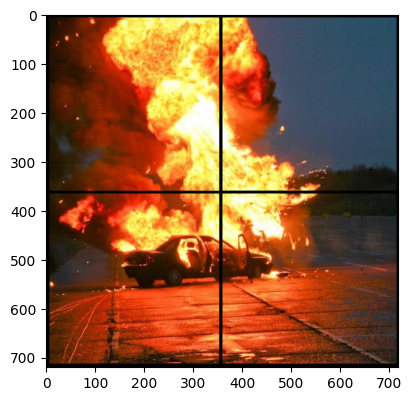

In [24]:
citra = plt.imread('Assets/Meledak.png')

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(citra)
plt.axis()

print(citra.shape)
plt.show

Kode tersebut digunakan untuk membaca dan menampilkan gambar `Meledak.png` menggunakan `matplotlib`. Fungsi `plt.imread()` membaca gambar, `plt.imshow()` menampilkan gambar, dan `print(citra.shape)` menampilkan ukuran citra. Sedangkan `plt.show` digunakan untuk menampilkan hasil akhirnya.


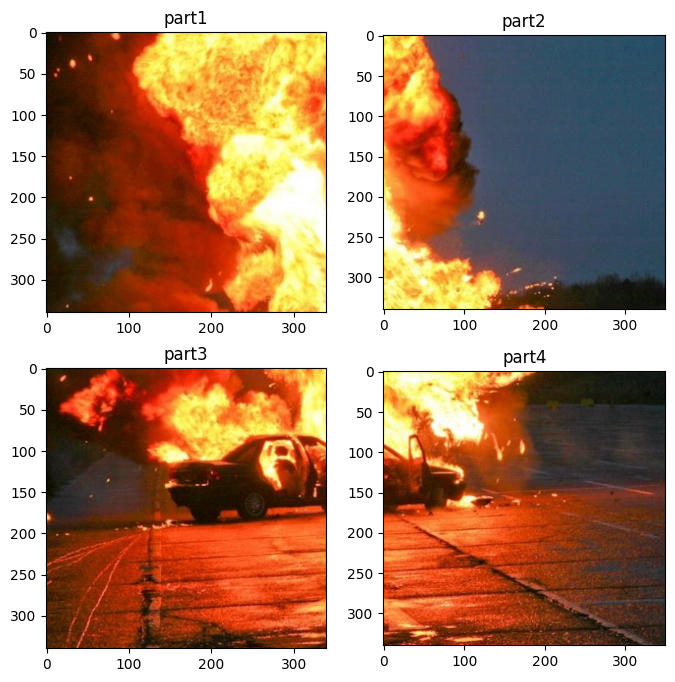

In [41]:
citra = plt.imread('Assets/Meledak.png')

def slice(gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

atas = slice(citra, 10, 350, 'H')
bawah = slice(citra, 370, 710, 'H')

part1 = slice(atas, 10, 350, 'V')
part2 = slice(atas, 360, 710, 'V')
part3 = slice(bawah, 10, 350, 'V')
part4 = slice(bawah, 360, 710, 'V')

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(part1)
plt.title("part1")

plt.subplot(2,2,2)
plt.imshow(part2)
plt.title("part2")

plt.subplot(2,2,3)
plt.imshow(part3)
plt.title("part3")

plt.subplot(2,2,4)
plt.imshow(part4)
plt.title("part4")
plt.show()

Kode tersebut digunakan untuk membagi citra `Meledak.png` menjadi 4 bagian. Fungsi `slice()` digunakan untuk memotong gambar secara horizontal (`H`) atau vertikal (`V`). Setelah citra dipotong menjadi bagian atas dan bawah, masing-masing bagian dipotong lagi menjadi kiri dan kanan sehingga menghasilkan `part1`, `part2`, `part3`, dan `part4`. Terakhir, keempat bagian gambar ditampilkan menggunakan `subplot`.


In [43]:
def merge(citra1, citra2, orientation='H'): 
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

Kode tersebut digunakan untuk menggabungkan dua citra menjadi satu menggunakan fungsi `merge()`. Jika parameter `orientation='H'`, maka gambar digabung secara horizontal (samping kanan-kiri), sedangkan selain itu gambar digabung secara vertikal (atas-bawah). Fungsi ini juga menyesuaikan ukuran array baru agar kedua citra dapat digabung dengan benar.


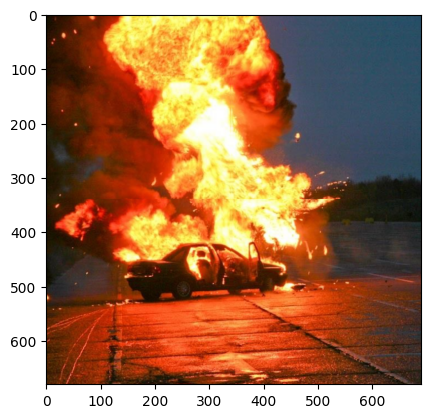

In [ ]:
atas_gabung = merge(part1, part2, 'H')
bawah_gabung = merge(part3, part4, 'H')
citra_utuh = merge(atas_gabung, bawah_gabung, 'V')

plt.imshow(citra_utuh)
plt.show()

Kode tersebut digunakan untuk menggabungkan kembali empat bagian citra (`part1`, `part2`, `part3`, dan `part4`) menjadi gambar utuh. Bagian atas dan bawah digabung secara horizontal terlebih dahulu, lalu kedua hasilnya digabung secara vertikal sehingga menghasilkan citra lengkap yang kemudian ditampilkan menggunakan `plt.imshow()`.


float32
0.0 1.0


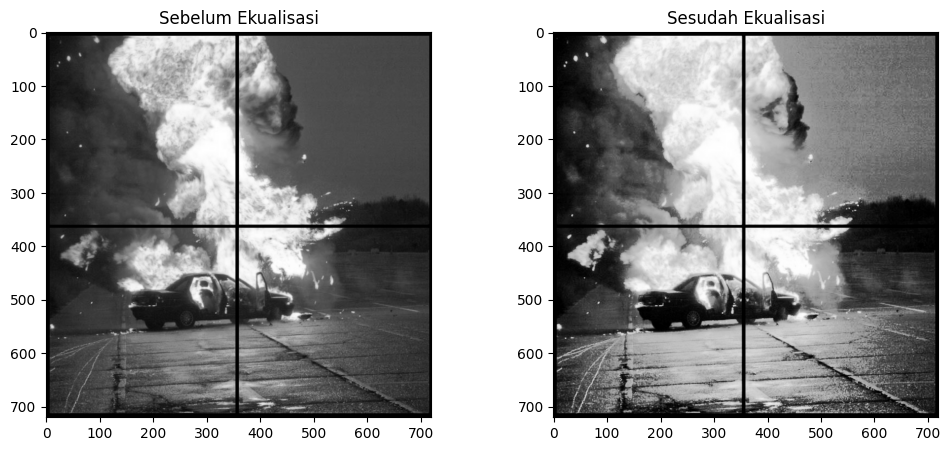

In [ ]:
def ekualisasi(citra):

    height, width = citra.shape

    hist = np.zeros(256, dtype=int)
    for y in range(height):
        for x in range(width):
            hist[citra[y, x]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)

    for y in range(height):
        for x in range(width):
            hasil[y, x] = cdf_normal[citra[y, x]]

    return hasil


print(citra_utuh.dtype)
print(citra_utuh.min(), citra_utuh.max())

if citra_utuh.max() <= 1:
    citra_fix = (citra_utuh * 255).astype(np.uint8)
else:
    citra_fix = citra_utuh.astype(np.uint8)

gray = cv2.cvtColor(citra_fix, cv2.COLOR_RGB2GRAY)

hasil_eq = ekualisasi(gray)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Sebelum Ekualisasi')
plt.axis()

plt.subplot(1,2,2)
plt.imshow(hasil_eq, cmap='gray')
plt.title('Sesudah Ekualisasi')
plt.axis()

plt.show()

Kode tersebut digunakan untuk melakukan ekualisasi histogram pada citra grayscale agar kontras gambar menjadi lebih jelas. Fungsi `ekualisasi()` menghitung histogram, mencari nilai CDF, lalu menyesuaikan intensitas piksel pada citra. Setelah gambar diubah ke grayscale menggunakan `cv2.cvtColor()`, hasil sebelum dan sesudah ekualisasi ditampilkan menggunakan `matplotlib`.


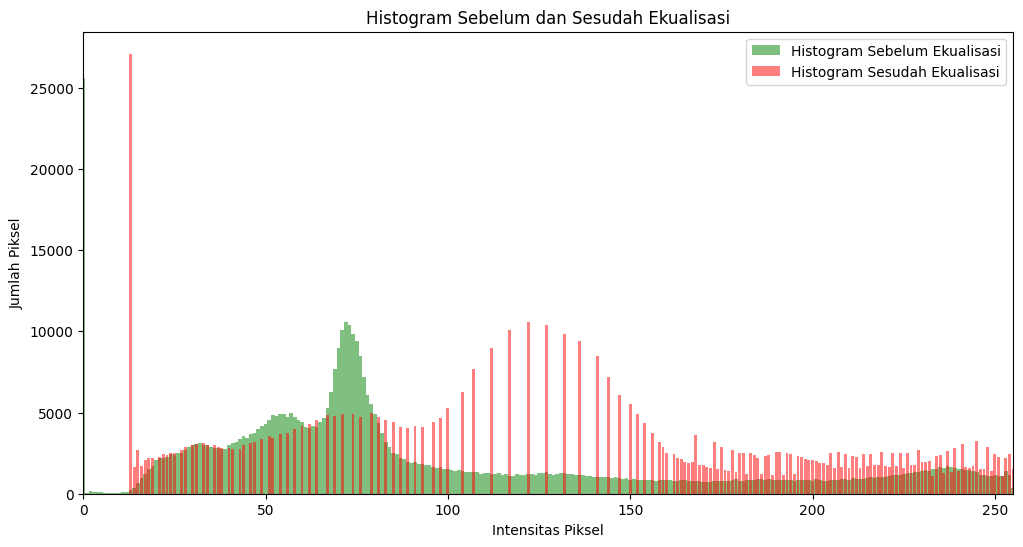

In [ ]:
def hitung_histogram(gambar):

    img_arr = np.array(gambar).astype(float)

    if len(img_arr.shape) == 3:
        img_arr = cv2.cvtColor(img_arr.astype(np.uint8), cv2.COLOR_RGB2GRAY)

    piksel_flat = img_arr.flatten()

    histogram = [0] * 256

    for p in piksel_flat:

        p = int(p)

        if 0 <= p <= 255:
            histogram[p] += 1

    return histogram

sebelum = hitung_histogram(gc1)

sesudah = hitung_histogram(hasil_eq)

x = np.arange(256)

plt.figure(figsize=(12,6))

plt.bar(
    x,
    sebelum,
    width=1.0,
    color='green',
    alpha=0.5,
    label='Histogram Sebelum Ekualisasi'
)

plt.bar(
    x,
    sesudah,
    width=0.8,
    color='red',
    alpha=0.5,
    label='Histogram Sesudah Ekualisasi'
)

plt.title('Histogram Sebelum dan Sesudah Ekualisasi')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')

plt.xlim(0,255)

plt.legend()

plt.show()

Kode tersebut digunakan untuk menghitung dan menampilkan histogram citra sebelum dan sesudah ekualisasi. Fungsi `hitung_histogram()` menghitung jumlah piksel untuk setiap intensitas 0–255. Histogram kemudian ditampilkan menggunakan diagram batang (`plt.bar`) dengan warna hijau untuk citra sebelum ekualisasi dan merah untuk citra sesudah ekualisasi agar perbedaan distribusi intensitas piksel dapat terlihat.


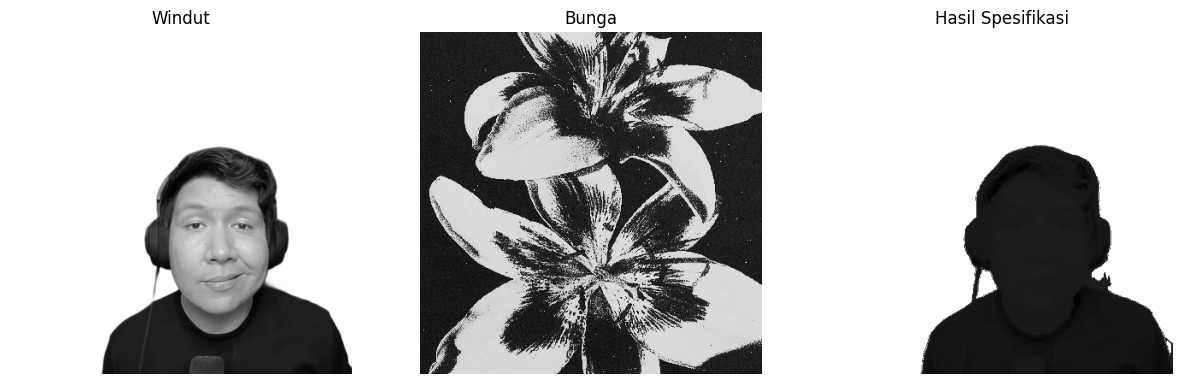

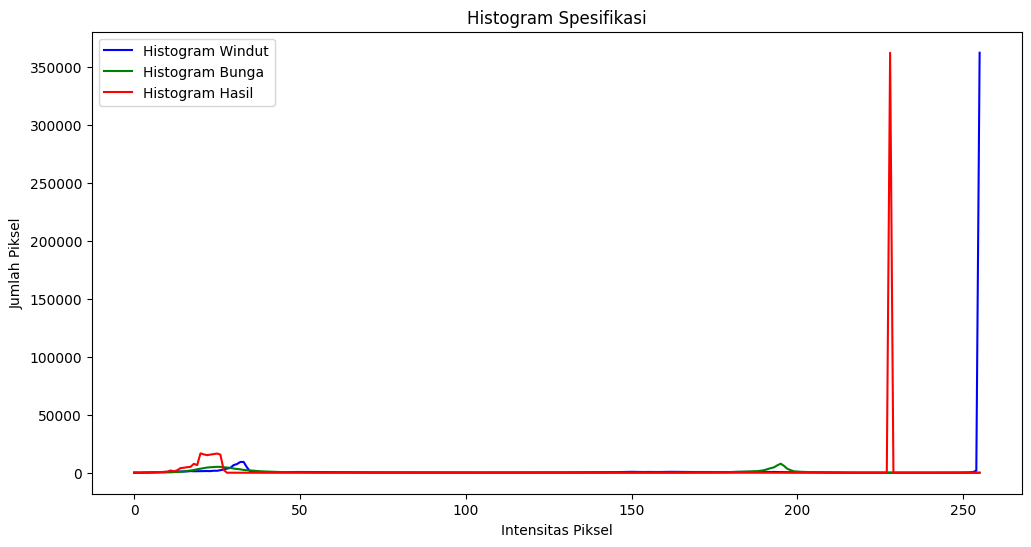

In [101]:
def hitung_histogram(gambar):

    histogram = [0] * 256

    height, width = gambar.shape

    for y in range(height):
        for x in range(width):

            nilai = gambar[y, x]
            histogram[nilai] += 1

    return histogram


def spesifikasi_histogram(citra_asal, citra_referensi):

    hist_asal = hitung_histogram(citra_asal)
    hist_ref = hitung_histogram(citra_referensi)

    cdf_asal = np.zeros(256)
    cdf_asal[0] = hist_asal[0]

    for i in range(1,256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]

    cdf_asal = cdf_asal / cdf_asal[-1]

    cdf_ref = np.zeros(256)
    cdf_ref[0] = hist_ref[0]

    for i in range(1,256):
        cdf_ref[i] = cdf_ref[i-1] + hist_ref[i]

    cdf_ref = cdf_ref / cdf_ref[-1]

    mapping = np.zeros(256, dtype=np.uint8)

    for i in range(256):

        selisih = np.abs(cdf_asal[i] - cdf_ref)
        mapping[i] = np.argmin(selisih)

    hasil = np.zeros_like(citra_asal)

    height, width = citra_asal.shape

    for y in range(height):
        for x in range(width):

            hasil[y, x] = mapping[citra_asal[y, x]]

    return hasil


windut = cv2.imread('Assets/Windut.png', 0)
bunga = cv2.imread('Assets/Bunga.png', 0)

hasil = spesifikasi_histogram(windut, bunga)

hist_windut = hitung_histogram(windut)
hist_bunga = hitung_histogram(bunga)
hist_hasil = hitung_histogram(hasil)

x = np.arange(256)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(windut, cmap='gray')
plt.title('Windut')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(bunga, cmap='gray')
plt.title('Bunga')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil, cmap='gray')
plt.title('Hasil Spesifikasi')
plt.axis('off')

plt.show()

plt.figure(figsize=(12,6))

plt.plot(x, hist_windut, color='blue', label='Histogram Windut')
plt.plot(x, hist_bunga, color='green', label='Histogram Bunga')
plt.plot(x, hist_hasil, color='red', label='Histogram Hasil')

plt.title('Histogram Spesifikasi')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')

plt.legend()
plt.show()

Kode tersebut digunakan untuk melakukan spesifikasi histogram, yaitu menyesuaikan distribusi intensitas citra asal (`Windut.png`) agar menyerupai citra referensi (`Bunga.png`). Program menghitung histogram dan CDF dari kedua citra, lalu membuat mapping intensitas piksel untuk menghasilkan citra baru dengan karakteristik histogram yang mirip dengan citra referensi. Hasil citra dan grafik histogram sebelum serta sesudah spesifikasi kemudian ditampilkan menggunakan `matplotlib`.


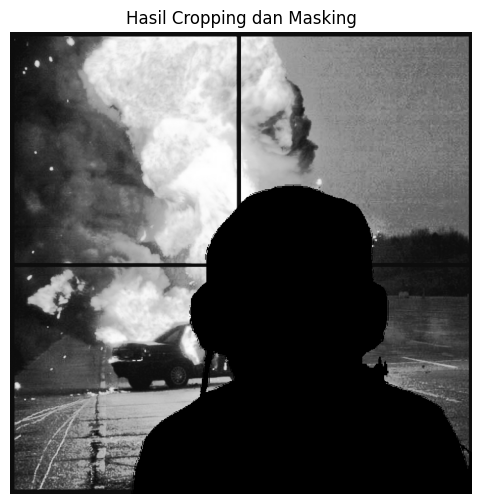

In [111]:
def crop_sama_ukuran(citra1, citra2):

    tinggi = min(citra1.shape[0], citra2.shape[0])
    lebar = min(citra1.shape[1], citra2.shape[1])

    citra1_crop = citra1[:tinggi, :lebar]
    citra2_crop = citra2[:tinggi, :lebar]

    return citra1_crop, citra2_crop


def buat_mask_threshold(citra, threshold=80):

    return citra < threshold


def terapkan_mask(background, mask):

    hasil = np.copy(background)
    hasil[mask] = 0

    return hasil


windut = hasil

windut_crop, background_crop = crop_sama_ukuran(
    windut,
    hasil_eq
)

mask = buat_mask_threshold(
    windut_crop,
    threshold=80
)

hasil_masking = terapkan_mask(
    background_crop,
    mask
)

plt.figure(figsize=(6,6))
plt.imshow(hasil_masking, cmap='gray')
plt.title("Hasil Cropping dan Masking")
plt.axis('off')
plt.show()

Kode tersebut digunakan untuk melakukan cropping dan masking pada citra. Fungsi `crop_sama_ukuran()` menyamakan ukuran dua citra dengan memotong bagian yang lebih besar, kemudian `buat_mask_threshold()` membuat mask berdasarkan nilai threshold piksel. Selanjutnya, fungsi `terapkan_mask()` menerapkan mask pada citra background sehingga area tertentu diubah menjadi hitam. Hasil akhirnya ditampilkan menggunakan `matplotlib`.


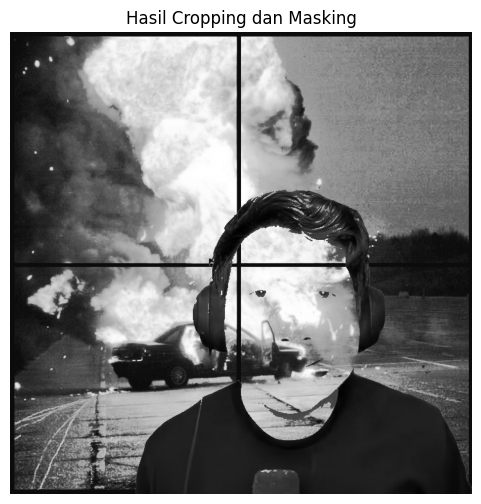

In [114]:
def crop_sama_ukuran(citra1, citra2):

    tinggi = min(citra1.shape[0], citra2.shape[0])
    lebar = min(citra1.shape[1], citra2.shape[1])

    citra1_crop = citra1[:tinggi, :lebar]
    citra2_crop = citra2[:tinggi, :lebar]

    return citra1_crop, citra2_crop


def buat_mask_threshold(citra, threshold=80):

    return citra < threshold


def terapkan_mask(background, objek, mask):

    hasil = np.copy(background)

    hasil[mask] = objek[mask]

    return hasil


windut_asli = cv2.imread('Assets/Windut.png', 0)

windut_crop, background_crop = crop_sama_ukuran(
    windut_asli,
    hasil_eq
)

mask = buat_mask_threshold(
    windut_crop,
    threshold=80
)

hasil_masking = terapkan_mask(
    background_crop,
    windut_crop,
    mask
)

plt.figure(figsize=(6,6))
plt.imshow(hasil_masking, cmap='gray')
plt.title("Hasil Cropping dan Masking")
plt.axis('off')
plt.show()